In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/blinkit_inventory.csv")

# Display the first 5 rows
df.head()

,product_id,date,stock_received,damaged_stock
0,153019,17-03-2023,4,2
1,848226,17-03-2023,4,2
2,965755,17-03-2023,1,0
3,39154,17-03-2023,4,0
4,34186,17-03-2023,3,2


In [2]:
# Dataset information
df.info()

# Statistical summary
df.describe()

# Check for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75172 entries, 0 to 75171
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   product_id      75172 non-null  int64 
 1   date            75172 non-null  object
 2   stock_received  75172 non-null  int64 
 3   damaged_stock   75172 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 2.3+ MB


product_id        0
date              0
stock_received    0
damaged_stock     0
dtype: int64

In [3]:
# Show all column names
print(df.columns)

Index(['product_id', 'date', 'stock_received', 'damaged_stock'], dtype='object')


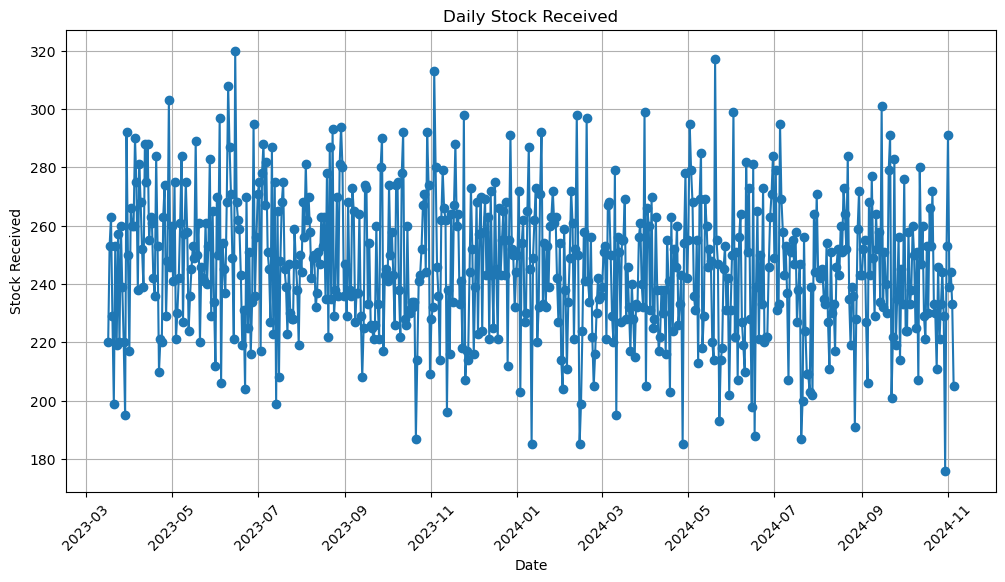

In [4]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Group data by date
daily_stock = df.groupby('date')['stock_received'].sum()

# Plot
plt.figure(figsize=(12,6))
plt.plot(daily_stock.index, daily_stock.values, marker='o')
plt.title("Daily Stock Received")
plt.xlabel("Date")
plt.ylabel("Stock Received")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

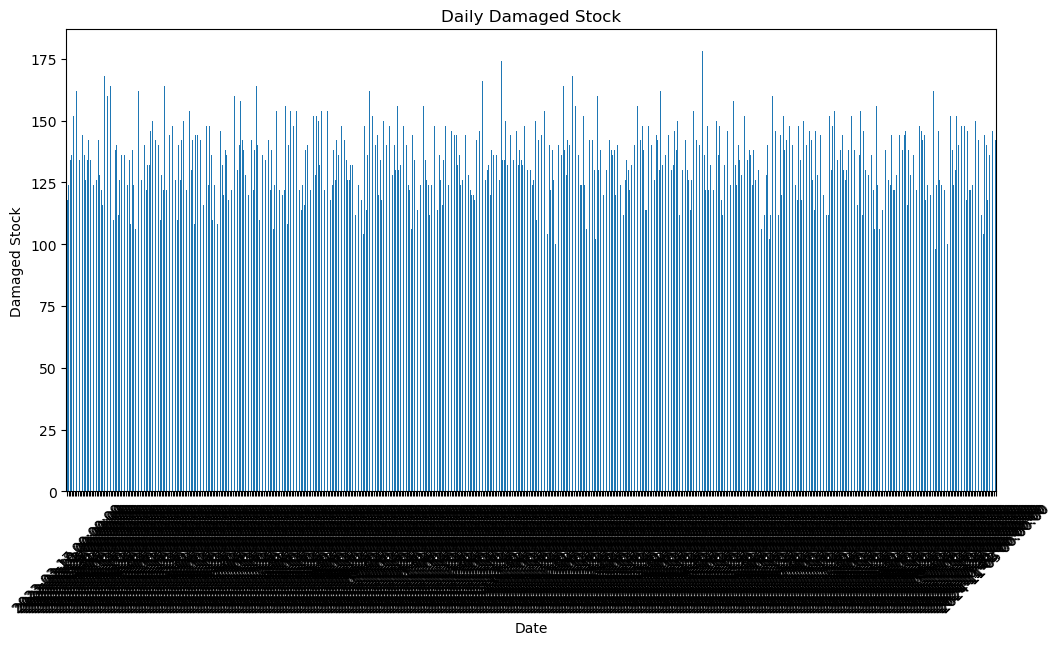

In [5]:
# Group damaged stock by date
daily_damaged = df.groupby('date')['damaged_stock'].sum()

plt.figure(figsize=(12,6))
daily_damaged.plot(kind='bar')
plt.title("Daily Damaged Stock")
plt.xlabel("Date")
plt.ylabel("Damaged Stock")
plt.xticks(rotation=45)
plt.show()

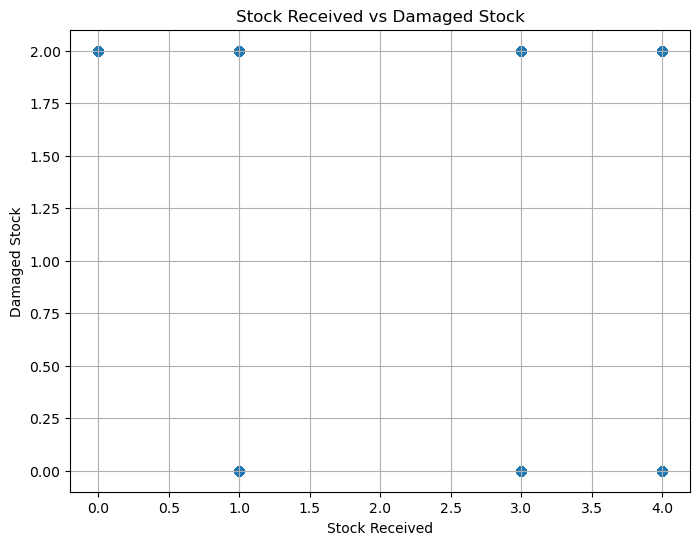

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(df['stock_received'], df['damaged_stock'])
plt.title("Stock Received vs Damaged Stock")
plt.xlabel("Stock Received")
plt.ylabel("Damaged Stock")
plt.grid(True)
plt.show()

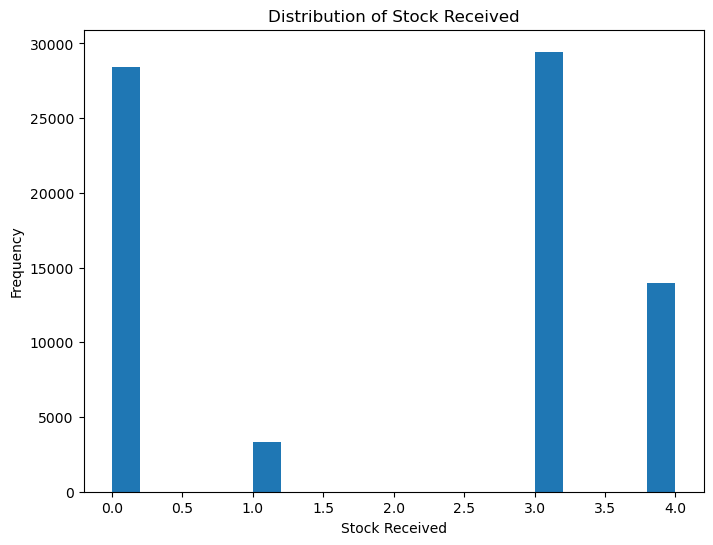

In [7]:
plt.figure(figsize=(8,6))
plt.hist(df['stock_received'], bins=20)
plt.title("Distribution of Stock Received")
plt.xlabel("Stock Received")
plt.ylabel("Frequency")
plt.show()

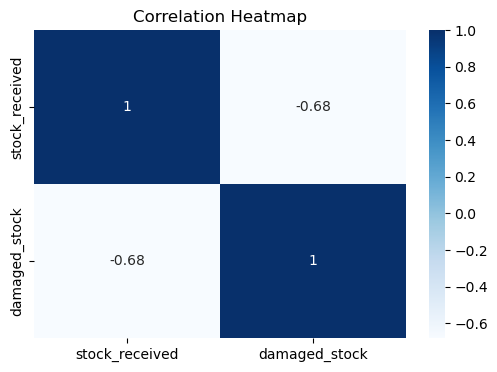

In [8]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(df[['stock_received','damaged_stock']].corr(),
            annot=True,
            cmap='Blues')

plt.title("Correlation Heatmap")
plt.show()